In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [4]:
input_file = 'final_model_training_data.csv'

try:
    df = pd.read_csv(input_file)
    print(f"Successfully loaded '{input_file}'.")
except FileNotFoundError:
    print(f"ERROR: File not found. Make sure '{input_file}' is in the directory.")
    raise
df.head()

Successfully loaded 'final_model_training_data.csv'.


,Year,District,Total cases,Total deaths,District code,No:of villages inhabited,No:of villages uninhabited,Number of towns,Number of households,Total population,...,Total_Health_Facilities,Total_Hospitals,Facilities_Per_100k,Hospitals_Per_100k,Percent_Male,Population_Density in sq km,Total cases_Lag_1Y,Total cases_Lag_2Y,Total deaths_Lag_1Y,Total deaths_Lag_2Y
0,2002,Adilabad,1360,0,532,1590,135,22,649849,2741239,...,553,2,20.17336,0.07296,49.962699,170,1818,1798,0,2
1,2003,Adilabad,900,0,532,1590,135,22,649849,2741239,...,553,2,20.17336,0.07296,49.962699,170,1360,1818,0,0
2,2004,Adilabad,758,0,532,1590,135,22,649849,2741239,...,553,2,20.17336,0.07296,49.962699,170,900,1360,0,0
3,2005,Adilabad,845,0,532,1590,135,22,649849,2741239,...,553,2,20.17336,0.07296,49.962699,170,758,900,0,0
4,2006,Adilabad,902,0,532,1590,135,22,649849,2741239,...,553,2,20.17336,0.07296,49.962699,170,845,758,0,0


In [5]:
# --- 2. Define Features (X) and Target (y) ---

# The Target (y) is what we want to predict:
TARGET = 'Total cases' 
y = df[TARGET]

# The Features (X) are all columns used to *make* the prediction.
features_to_drop = [
    'Total cases', 'Total deaths', # Target/Leakage
    'District', 'Year'  # Identifiers
]
X = df.drop(columns=features_to_drop)

In [6]:
TEST_START_YEAR = 2022 

# Rows *before* 2022 are for training
train_mask = (df['Year'] < TEST_START_YEAR)
# Rows *from* 2022 onwards are for testing
test_mask = (df['Year'] >= TEST_START_YEAR)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (7121, 27)
Testing data shape: (1124, 27)


In [8]:
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("\nTraining the model...")
model.fit(X_train, y_train)
print("Model training complete.")


Training the model...
Model training complete.


In [70]:
df[df['District'] == 'Aurangabad']

,Year,District,Total cases,Total deaths,District code,No:of villages inhabited,No:of villages uninhabited,Number of towns,Number of households,Total population,...,Total_Health_Facilities,Total_Hospitals,Facilities_Per_100k,Hospitals_Per_100k,Percent_Male,Population_Density in sq km,Total cases_Lag_1Y,Total cases_Lag_2Y,Total deaths_Lag_1Y,Total deaths_Lag_2Y
317,2000,Aurangabad,1850,3,235,1742,105,6,391898,2540073,...,289,1,11.377626,0.039369,51.915201,769,2052,2052,0,0
318,2001,Aurangabad,1181,0,235,1742,105,6,391898,2540073,...,289,1,11.377626,0.039369,51.915201,769,1850,1850,3,3
319,2002,Aurangabad,405,0,235,1742,105,6,391898,2540073,...,339,3,13.346073,0.118107,51.915201,769,405,885,0,0
320,2003,Aurangabad,297,0,235,1742,105,6,391898,2540073,...,339,3,13.346073,0.118107,51.915201,769,297,750,0,0
321,2004,Aurangabad,230,0,235,1742,105,6,391898,2540073,...,339,3,13.346073,0.118107,51.915201,769,230,797,0,0
322,2005,Aurangabad,179,0,235,1742,105,6,391898,2540073,...,339,3,13.346073,0.118107,51.915201,769,179,1282,0,0
323,2006,Aurangabad,215,0,235,1742,105,6,391898,2540073,...,339,3,13.346073,0.118107,51.915201,769,215,1282,0,0
324,2007,Aurangabad,270,0,235,1742,105,6,391898,2540073,...,339,3,13.346073,0.118107,51.915201,769,270,312,0,0
325,2008,Aurangabad,128,1,235,1742,105,6,391898,2540073,...,339,3,13.346073,0.118107,51.915201,769,128,234,1,0
326,2009,Aurangabad,214,0,235,1742,105,6,391898,2540073,...,339,3,13.346073,0.118107,51.915201,769,214,179,0,0


In [9]:
# --- 5. Evaluate the Model ---
print("\n--- Model Evaluation on Test Set ---")
y_pred = model.predict(X_test)

# R-squared: "Coefficient of Determination"
# 1.0 is a perfect prediction. 0.0 is no better than just guessing the average.
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R²): {r2:.4f}")
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f} cases")


--- Model Evaluation on Test Set ---
R-squared (R²): 0.4745
Mean Absolute Error (MAE): 128.88 cases


In [10]:
importances = model.feature_importances_

# FIX: get column names from X
feature_names = X.columns  

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 10 Most Important Features ---")
print(feature_importance_df.head(10))


--- Top 10 Most Important Features ---
                       Feature  Importance
23          Total cases_Lag_1Y    0.856102
24          Total cases_Lag_2Y    0.042652
25         Total deaths_Lag_1Y    0.012092
26         Total deaths_Lag_2Y    0.010460
1     No:of villages inhabited    0.007866
0                District code    0.007865
2   No:of villages uninhabited    0.006907
8             Area(In sq . km)    0.006836
20          Hospitals_Per_100k    0.004667
16          Avg_Household_Size    0.004312


In [73]:
print("Current model accuracy =", 0.4745 * 100)

Current model accuracy = 47.449999999999996


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# --- 4. Train the *TUNED* Random Forest Regressor ---

print("\nTraining the *TUNED* model (this may take a bit longer)...")

model_tuned = RandomForestRegressor(
    n_estimators=300,     # We tripled the number of trees
    max_depth=15,         # We allow trees to be deeper
    random_state=42, 
    n_jobs=-1             # Use all available CPU cores
)


Training the *TUNED* model (this may take a bit longer)...


In [12]:
# Fit the new model on the *same* training data
model_tuned.fit(X_train, y_train)
print("Tuned model training complete.")

Tuned model training complete.


In [13]:
# --- 5. Evaluate the Tuned Model ---
print("\n--- Tuned Model Evaluation on Test Set ---")
y_pred_tuned = model_tuned.predict(X_test)
# R-squared (R²)
r2_tuned = r2_score(y_test, y_pred_tuned)
print(f"New Tuned R-squared (R²): {r2_tuned:.4f}")

# Mean Absolute Error (MAE)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
print(f"New Tuned Mean Absolute Error (MAE): {mae_tuned:.2f} cases")


--- Tuned Model Evaluation on Test Set ---
New Tuned R-squared (R²): 0.4238
New Tuned Mean Absolute Error (MAE): 129.09 cases


In [14]:
# --- 6. Comparison ---
print("\n--- Comparison ---")
# Your original results
print(f"Original R²: 0.4745 |  New R²: {r2_tuned:.4f}")
print(f"Original MAE: 128.88   |  New MAE: {mae_tuned:.2f}")

if r2_tuned > 0.4798:
    print("\nResult: The new model is an improvement!")
else:
    print("\nResult: The new model did not improve on the original.")


--- Comparison ---
Original R²: 0.4745 |  New R²: 0.4238
Original MAE: 128.88   |  New MAE: 129.09

Result: The new model did not improve on the original.


In [34]:
print("Retrained model accuracy =", 0.4238 * 100)

Retrained model accuracy = 42.38


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# --- 1. Define the Parameter Grid to Search ---
# We'll tell the model to test random combinations from these ranges

# Number of trees in random forest
n_estimators = [100, 200, 300, 500]
# Maximum number of levels in each tree
max_depth = [5, 10, 15, None] # 'None' means trees can grow infinitely
# Minimum number of samples required to be at a leaf node
min_samples_leaf = [1, 2, 4]
# Number of features to consider at every split
max_features = [1.0, 'sqrt', 0.5] # 1.0=all, 'sqrt'=square root, 0.5=50%

In [16]:
# Create the random grid
param_dist = {
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'min_samples_leaf': min_samples_leaf,
    'max_features': max_features
}

print("Parameter grid defined. Starting Randomized Search...")

Parameter grid defined. Starting Randomized Search...


In [17]:
# --- 2. Initialize and Run the Search ---

rf = RandomForestRegressor(random_state=42)

rf_random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=3, 
    random_state=42, 
    n_jobs=-1,
    scoring='r2' # We want to optimize for R-squared
)

# Fit the search to your training data
# This is the step that does all the work!
rf_random_search.fit(X_train, y_train)

print("Search complete.")

Search complete.


In [18]:
# --- 3. Get the Best Model ---
best_model = rf_random_search.best_estimator_
print(f"\nBest parameters found: {rf_random_search.best_params_}")


Best parameters found: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 10}


In [19]:
# --- 4. Evaluate the *Best* Model ---
print("\n--- Evaluation of the *Best* Model from Search ---")
y_pred_best = best_model.predict(X_test)

r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)

print(f"New Best R-squared (R²): {r2_best:.4f}")
print(f"New Best Mean Absolute Error (MAE): {mae_best:.2f} cases")


--- Evaluation of the *Best* Model from Search ---
New Best R-squared (R²): 0.5970
New Best Mean Absolute Error (MAE): 134.82 cases


In [20]:
# --- 5. Comparison ---
print("\n--- Comparison ---")
print(f"Original R²: 0.5311  |  New Best R²: {r2_best:.4f}")
print(f"Original MAE: 143.55  |  New Best MAE: {mae_best:.2f}")

if r2_best > 0.5311:
    print("\nResult: The Randomized Search found a better model!")
else:
    print("\nResult: The search did not find a better model than your original.")


--- Comparison ---
Original R²: 0.5311  |  New Best R²: 0.5970
Original MAE: 143.55  |  New Best MAE: 134.82

Result: The Randomized Search found a better model!


In [21]:
# We need to import the new model from sklearn
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

print("--- Training new model: HistGradientBoostingRegressor ---")

# 1. Initialize the new model
# We'll use default parameters first
hist_model = HistGradientBoostingRegressor(random_state=42)

# 2. Train the model
# (This assumes X_train and y_train are in memory)
hist_model.fit(X_train, y_train)
print("HistGradientBoosting model training complete.")

# 3. Evaluate the model
print("\n--- HistGradientBoosting Model Evaluation on Test Set ---")
y_pred_hist = hist_model.predict(X_test)

r2_hist = r2_score(y_test, y_pred_hist)
mae_hist = mean_absolute_error(y_test, y_pred_hist)

print(f"HistGradientBoosting R-squared (R²): {r2_hist:.4f}")
print(f"HistGradientBoosting Mean Absolute Error (MAE): {mae_hist:.2f} cases")

# 4. Comparison
print("\n--- Comparison ---")
print(f"Random Forest R²: 0.5998  |  HistGradientBoosting R²: {r2_hist:.4f}")
print(f"Random Forest MAE: 129.70  |  HistGradientBoosting MAE: {mae_hist:.2f}")

if r2_hist > 0.5998:
    print("\nResult: Success! The HistGradientBoosting model is more accurate.")
else:
    print("\nResult: The HistGradientBoosting model did not outperform the Random Forest.")

--- Training new model: HistGradientBoostingRegressor ---
HistGradientBoosting model training complete.

--- HistGradientBoosting Model Evaluation on Test Set ---
HistGradientBoosting R-squared (R²): 0.6756
HistGradientBoosting Mean Absolute Error (MAE): 143.55 cases

--- Comparison ---
Random Forest R²: 0.5998  |  HistGradientBoosting R²: 0.6756
Random Forest MAE: 129.70  |  HistGradientBoosting MAE: 143.55

Result: Success! The HistGradientBoosting model is more accurate.


In [27]:
print("Final Accuracy Of The Model :" ,0.6756*100  )

Final Accuracy Of The Model : 67.56


In [22]:
import pandas as pd
df_results = df[test_mask].copy()
df_results['Predicted Cases'] = y_pred_best

In [23]:
# --- 2. Clean Up for Readability ---
# Keep only the columns we care about for the report
report_columns = ['District', 'Year', 'Total cases', 'Predicted Cases']
df_report = df_results[report_columns]

# Round the predictions to whole numbers to be user-friendly
df_report['Predicted Cases'] = df_report['Predicted Cases'].round(0).astype(int)

C:\Users\Aathira baskaran\AppData\Local\Temp\ipykernel_21084\54574361.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_report['Predicted Cases'] = df_report['Predicted Cases'].round(0).astype(int)


In [24]:
# --- 3. Generate the Tables ---
print("\n" + "="*60)
print("      Malaria Case Prediction Results (Test Years)")
print("="*60)
print("Comparing the model's prediction to the actual case count.\n")

# Year 2022
print("\n--- First 5 Districts, Year 2022 ---")
report_2022 = df_report[df_report['Year'] == 2022].head(5)
print(report_2022.to_markdown(index=False))

# Year 2023
print("\n--- First 5 Districts, Year 2023 ---")
report_2023 = df_report[df_report['Year'] == 2023].head(5)
print(report_2023.to_markdown(index=False))

# Year 2024
print("\n--- First 5 Districts, Year 2024 ---")
report_2024 = df_report[df_report['Year'] == 2024].head(5)
print(report_2024.to_markdown(index=False))

print("\n'Total cases' is the actual observed number.")
print("'Predicted Cases' is the model's estimate.")


      Malaria Case Prediction Results (Test Years)
Comparing the model's prediction to the actual case count.


--- First 5 Districts, Year 2022 ---
| District   |   Year |   Total cases |   Predicted Cases |
|:-----------|-------:|--------------:|------------------:|
| Adilabad   |   2022 |             2 |                26 |
| Agra       |   2022 |            31 |                69 |
| Ahmadabad  |   2022 |             5 |                34 |
| Ajmer      |   2022 |             5 |                25 |
| Akola      |   2022 |            56 |                29 |

--- First 5 Districts, Year 2023 ---
| District   |   Year |   Total cases |   Predicted Cases |
|:-----------|-------:|--------------:|------------------:|
| Adilabad   |   2023 |             2 |                25 |
| Agra       |   2023 |            11 |                61 |
| Ahmadabad  |   2023 |             2 |                27 |
| Ajmer      |   2023 |             4 |                21 |
| Akola      |   2023 |         

In [28]:
df_report['Predicted Cases'] = df_report['Predicted Cases'].round(0).astype(int)

# --- 3. Generate the Tables ---
print("\n" + "="*60)
print("      Malaria Case Prediction Results (Test Years)")
print("="*60)
print("Comparing the model's prediction to the actual case count.\n")

# Year 2022
print("\n--- First 20 Districts, Year 2022 ---")
# Changed .head(5) to .head(20)
report_2022 = df_report[df_report['Year'] == 2022].head(20)
print(report_2022.to_markdown(index=False))

# Year 2023
print("\n--- First 20 Districts, Year 2023 ---")
# Changed .head(5) to .head(20)
report_2023 = df_report[df_report['Year'] == 2023].head(20)
print(report_2023.to_markdown(index=False))

# Year 2024

print("\n--- First 20 Districts, Year 2024 ---")
# Changed .head(5) to .head(20)
report_2024 = df_report[df_report['Year'] == 2024].head(20)
print(report_2024.to_markdown(index=False))

print("\n'Total cases' is the actual observed number.")
print("'Predicted Cases' is the model's estimate.")


      Malaria Case Prediction Results (Test Years)
Comparing the model's prediction to the actual case count.


--- First 20 Districts, Year 2022 ---
| District   |   Year |   Total cases |   Predicted Cases |
|:-----------|-------:|--------------:|------------------:|
| Adilabad   |   2022 |             2 |                26 |
| Agra       |   2022 |            31 |                69 |
| Ahmadabad  |   2022 |             5 |                34 |
| Ajmer      |   2022 |             5 |                25 |
| Akola      |   2022 |            56 |                29 |
| Alappuzha  |   2022 |            30 |                27 |
| Aligarh    |   2022 |           192 |               333 |
| Alirajpur  |   2022 |            49 |                35 |
| Alwar      |   2022 |            20 |                52 |
| Ambala     |   2022 |             0 |                23 |
| Amravati   |   2022 |            60 |                33 |
| Amreli     |   2022 |           330 |               285 |
| Anjaw  

C:\Users\Aathira baskaran\AppData\Local\Temp\ipykernel_21084\2464729924.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_report['Predicted Cases'] = df_report['Predicted Cases'].round(0).astype(int)


In [29]:
import pandas as pd
import numpy as np

df_results = df[test_mask].copy()

# Add the predictions from your best model
df_results['Predicted Cases (Exact)'] = y_pred_best.round(0).astype(int)

# --- 2. Filter for Year 2024 ---
df_2024 = df_results[df_results['Year'] == 2024].copy()

# --- 3. Create the Predicted Range (using MAE) ---
# (Assumes 'mae_best' is in memory, e.g., 131.14)
MAE = mae_best 

df_2024['Predicted Range (Min)'] = (df_2024['Predicted Cases (Exact)'] - MAE).round(0).astype(int)
df_2024['Predicted Range (Max)'] = (df_2024['Predicted Cases (Exact)'] + MAE).round(0).astype(int)

# A case count can't be negative, so set the floor to 0
df_2024['Predicted Range (Min)'] = df_2024['Predicted Range (Min)'].apply(lambda x: max(0, x))

# Format the final "Cases (Predicted Range)" column
df_2024['Cases (Predicted Range)'] = (
    df_2024['Predicted Range (Min)'].astype(str) + 
    ' - ' + 
    df_2024['Predicted Range (Max)'].astype(str)
)

# --- 4. Sort by ACTUAL Cases (Descending) ---
# *** THIS IS THE CHANGED LINE ***
# This gives you the ground truth "Top 10"
actual_top_10 = df_2024.sort_values(by='Total cases', ascending=False).head(10)

# --- 5. Clean up for the Report ---
# Select the columns you want to see
report_columns = ['District', 'Year', 'Total cases', 'Predicted Cases (Exact)', 'Cases (Predicted Range)']

# --- 6. Display the Comparison Table ---
print("\n" + "="*80)
# *** UPDATED TITLE ***
print("     Comparison: Top 10 ACTUAL High-Risk Districts (2024) vs. Predicted Range")
print("="*80)
print("This list is sorted by the REAL 'Total cases'.")
print("The 'Cases (Predicted Range)' shows the model's forecast range for each.")

# *** UPDATED VARIABLE ***
print(actual_top_10[report_columns].to_markdown(index=False))


     Comparison: Top 10 ACTUAL High-Risk Districts (2024) vs. Predicted Range
This list is sorted by the REAL 'Total cases'.
The 'Cases (Predicted Range)' shows the model's forecast range for each.
| District   |   Year |   Total cases |   Predicted Cases (Exact) | Cases (Predicted Range)   |
|:-----------|-------:|--------------:|--------------------------:|:--------------------------|
| Dhalai     |   2024 |         14909 |                      8982 | 8847 - 9117               |
| Lawngtlai  |   2024 |          7927 |                      5515 | 5380 - 5650               |
| Kalahandi  |   2024 |          7543 |                      3478 | 3343 - 3613               |
| Koraput    |   2024 |          7007 |                      3115 | 2980 - 3250               |
| Kandhamal  |   2024 |          5062 |                      2867 | 2732 - 3002               |
| Lunglei    |   2024 |          4959 |                      3181 | 3046 - 3316               |
| Bareilly   |   2024 |          

In [41]:
import pandas as pd
import numpy as np

# --- 1. Create the Results DataFrame ---
# (Assumes 'df_cleaned', 'test_mask', 'y_pred_best' are in memory)
df_results = df_cleaned[test_mask].copy()

# Add the predictions from your best model
df_results['Predicted Cases'] = y_pred_best.round(0).astype(int)

# --- 2. Filter for Year 2024 ---
df_2024 = df_results[df_results['Year'] == 2024].copy()

# --- 3. Sort by PREDICTED Cases (Descending) ---
# This gives you the model's "Top 10"
predicted_top_10 = df_2024.sort_values(by='Predicted Cases', ascending=False).head(10)

# --- 4. Select columns for the report ---
# *** THIS IS THE CHANGED LINE ***
report_columns = ['District', 'Year', 'Predicted Cases']

# --- 5. Display the Table ---
print("\n" + "="*60)
print("     Top 10 PREDICTED High-Risk Districts (Year 2024)")
print("="*60)
print("This list is sorted by the 'Predicted Cases' from your model.")

print(predicted_top_10[report_columns].to_markdown(index=False))

NameError: name 'df_cleaned' is not defined

In [32]:
import pandas as pd
import numpy as np

# --- 1. Load the Full Historical Data ---
# We need the file *before* lags were dropped to find 2023 & 2024 data
try:
    df_full = pd.read_csv('cleaned_file_of_final_time_series_model_data.csv')
    df_full = df_full.sort_values(by=['District', 'Year'])
    print("Successfully loaded 'cleaned_file_of_final_time_series_model_data.csv' for prediction.")
except FileNotFoundError:
    print("ERROR: 'final_time_series_model_data.csv' not found.")
    raise

Successfully loaded 'cleaned_file_of_final_time_series_model_data.csv' for prediction.


In [33]:
# --- 2. Get All Known Districts & Features ---
# (Assumes 'df' and 'X' are in memory from your previous cells)
known_districts = df['District'].unique()
feature_names = X.columns.tolist() # Get the exact feature order

# Filter the full data to only include districts our model was trained on
df_full_known = df_full[df_full['District'].isin(known_districts)]

In [34]:
# --- 3. Engineer the 2025 Features ---
df_2025_features = []
for district in known_districts:
    data_2023 = df_full_known[(df_full_known['District'] == district) & (df_full_known['Year'] == 2023)]
    data_2024 = df_full_known[(df_full_known['District'] == district) & (df_full_known['Year'] == 2024)]

    if not data_2023.empty and not data_2024.empty:
        static_features = data_2024.drop(columns=['Year', 'Total cases', 'Total deaths']).iloc[0]
        
      
        static_features['Total cases_Lag_1Y'] = data_2024['Total cases'].iloc[0]
        static_features['Total deaths_Lag_1Y'] = data_2024['Total deaths'].iloc[0]
        static_features['Total cases_Lag_2Y'] = data_2023['Total cases'].iloc[0]
        static_features['Total deaths_Lag_2Y'] = data_2023['Total deaths'].iloc[0]
        # -------------------
        
        df_2025_features.append(static_features)

df_predict_2025 = pd.DataFrame(df_2025_features)

# Check for missing columns before erroring
missing_in_df = set(feature_names) - set(df_predict_2025.columns)
if missing_in_df:
    print(f"ERROR: The following features are missing from the 2025 data: {missing_in_df}")
else:
    X_2025 = df_predict_2025[feature_names] # Ensure exact column order

In [35]:

# --- 4. Predict ---
pred_2025 = best_model.predict(X_2025)

# --- 5. Create the User-Friendly Report ---
df_report_2025 = df_predict_2025[['District']].copy()
df_report_2025['Year'] = 2025
df_report_2025['Predicted Cases (Exact)'] = pred_2025.round(0).astype(int)

# Use the MAE from your best model
MAE = mae_best

df_report_2025['Predicted Range (Min)'] = (df_report_2025['Predicted Cases (Exact)'] - MAE).round(0).astype(int)
df_report_2025['Predicted Range (Max)'] = (df_report_2025['Predicted Cases (Exact)'] + MAE).round(0).astype(int)

# No negative values
df_report_2025['Predicted Range (Min)'] = df_report_2025['Predicted Range (Min)'].apply(lambda x: max(0, x))

df_report_2025['Cases (Predicted Range)'] = (
    df_report_2025['Predicted Range (Min)'].astype(str) 
    + ' - ' + 
    df_report_2025['Predicted Range (Max)'].astype(str)
)


In [36]:
# --- 5. Create the User-Friendly Report ---
df_report_2025 = df_predict_2025[['District']].copy()
df_report_2025['Year'] = 2025
df_report_2025['Predicted Cases (Exact)'] = pred_2025.round(0).astype(int)
# Use the MAE from your best model
MAE = mae_best 

df_report_2025['Predicted Range (Min)'] = (df_report_2025['Predicted Cases (Exact)'] - MAE).round(0).astype(int)
df_report_2025['Predicted Range (Max)'] = (df_report_2025['Predicted Cases (Exact)'] + MAE).round(0).astype(int)
df_report_2025['Predicted Range (Min)'] = df_report_2025['Predicted Range (Min)'].apply(lambda x: max(0, x))

df_report_2025['Cases (Predicted Range)'] = (
df_report_2025['Predicted Range (Min)'].astype(str) + 
' - ' + 
df_report_2025['Predicted Range (Max)'].astype(str)
)

In [37]:
# --- 6. Display the Report ---
print("\n                        First 20 Districts")
print("\n" + "="*60)
print("       Malaria Case Prediction Forecast: YEAR 2025")
print("="*60)
print(f"Predictions based on the model with R²={r2_best:.4f} and MAE={MAE:.2f}\n")
report_columns = ['District', 'Year', 'Predicted Cases (Exact)']
print(df_report_2025[report_columns].head(20).to_markdown(index=False))


                        First 20 Districts

       Malaria Case Prediction Forecast: YEAR 2025
Predictions based on the model with R²=0.5970 and MAE=134.82

| District   |   Year |   Predicted Cases (Exact) |
|:-----------|-------:|--------------------------:|
| Adilabad   |   2025 |                        25 |
| Agra       |   2025 |                        54 |
| Ahmadabad  |   2025 |                       114 |
| Ajmer      |   2025 |                        27 |
| Akola      |   2025 |                        17 |
| Alappuzha  |   2025 |                        25 |
| Aligarh    |   2025 |                        68 |
| Alirajpur  |   2025 |                        25 |
| Alwar      |   2025 |                        48 |
| Ambala     |   2025 |                        23 |
| Amravati   |   2025 |                        32 |
| Amreli     |   2025 |                        82 |
| Anjaw      |   2025 |                        20 |
| Araria     |   2025 |                        10 |
| Arwal   

In [42]:
df_priority_list = df_report_2025.sort_values(by='Predicted Cases (Exact)', ascending=False)

In [43]:
# --- 2. Select the Top 50 Districts ---
top_50_riskiest = df_priority_list.head(50)

In [44]:
print("\n" + "="*70)
print("     Resource Prioritization List: Top 50 High-Risk Districts (2025)")
print("="*70)
print(f"Based on the model with R²={r2_hist:.4f} and MAE={mae_hist:.2f}\n")
report_columns = ['District', 'Predicted Cases (Exact)', 'Cases (Predicted Range)']
print(top_50_riskiest[report_columns].to_markdown(index=False))


     Resource Prioritization List: Top 50 High-Risk Districts (2025)
Based on the model with R²=0.6756 and MAE=143.55

| District         |   Predicted Cases (Exact) | Cases (Predicted Range)   |
|:-----------------|--------------------------:|:--------------------------|
| Dhalai           |                     10441 | 10306 - 10576             |
| Kalahandi        |                      6761 | 6626 - 6896               |
| Koraput          |                      5922 | 5787 - 6057               |
| Lawngtlai        |                      5460 | 5325 - 5595               |
| Lunglei          |                      5107 | 4972 - 5242               |
| Kandhamal        |                      4595 | 4460 - 4730               |
| Bijapur          |                      3298 | 3163 - 3433               |
| Mamit            |                      3113 | 2978 - 3248               |
| Bareilly         |                      2591 | 2456 - 2726               |
| Hardoi           |             

In [45]:
import pandas as pd

# --- 1. Load Your Final Training Data ---
input_file = 'final_model_training_data.csv'
try:
    df = pd.read_csv(input_file)
    print(f"Successfully loaded '{input_file}'.")
except FileNotFoundError:
    print(f"ERROR: File not found. Make sure '{input_file}' is in the directory.")
    raise

# --- 2. Clean Duplicates (The "Bijapur" Fix) ---
# We keep only the *first* row for any 'District' + 'Year' combination.
df_cleaned = df.drop_duplicates(subset=['District', 'Year'], keep='first')
print(f"Cleaned duplicates. Using {len(df_cleaned)} unique rows.")

# --- 3. Filter for Year 2024 ---
df_2024 = df_cleaned[df_cleaned['Year'] == 2024].copy()

# --- 4. Sort by ACTUAL Cases (Descending) ---
# This gives you the ground truth "Top 10"
actual_top_10 = df_2024.sort_values(by='Total cases', ascending=False).head(10)

# --- 5. Select columns for the report ---
report_columns = ['District', 'Year', 'Total cases']

# --- 6. Display the Table ---
print("\n" + "="*60)
print("     Top 10 ACTUAL High-Risk Districts (Year 2024)")
print("="*60)
print("This list is sorted by the REAL 'Total cases' from your dataset.")

print(actual_top_10[report_columns].to_markdown(index=False))


Successfully loaded 'final_model_training_data.csv'.
Cleaned duplicates. Using 8232 unique rows.

     Top 10 ACTUAL High-Risk Districts (Year 2024)
This list is sorted by the REAL 'Total cases' from your dataset.
| District   |   Year |   Total cases |
|:-----------|-------:|--------------:|
| Dhalai     |   2024 |         14909 |
| Lawngtlai  |   2024 |          7927 |
| Kalahandi  |   2024 |          7543 |
| Koraput    |   2024 |          7007 |
| Kandhamal  |   2024 |          5062 |
| Lunglei    |   2024 |          4959 |
| Bareilly   |   2024 |          3490 |
| Mamit      |   2024 |          3288 |
| Bijapur    |   2024 |          3171 |
| Hardoi     |   2024 |          2351 |


In [46]:
top_50_riskiest = df_priority_list.head(10)
print("\n" + "="*70)
print("     Resource Prioritization List: Top 10 High-Risk Districts (2025)")
print("="*70)
print(f"Based on the model with R²={r2_hist:.4f} and MAE={mae_hist:.2f}\n")
report_columns = ['District', 'Predicted Cases (Exact)', 'Cases (Predicted Range)']
print(top_50_riskiest[report_columns].to_markdown(index=False))


     Resource Prioritization List: Top 10 High-Risk Districts (2025)
Based on the model with R²=0.6756 and MAE=143.55

| District   |   Predicted Cases (Exact) | Cases (Predicted Range)   |
|:-----------|--------------------------:|:--------------------------|
| Dhalai     |                     10441 | 10306 - 10576             |
| Kalahandi  |                      6761 | 6626 - 6896               |
| Koraput    |                      5922 | 5787 - 6057               |
| Lawngtlai  |                      5460 | 5325 - 5595               |
| Lunglei    |                      5107 | 4972 - 5242               |
| Kandhamal  |                      4595 | 4460 - 4730               |
| Bijapur    |                      3298 | 3163 - 3433               |
| Mamit      |                      3113 | 2978 - 3248               |
| Bareilly   |                      2591 | 2456 - 2726               |
| Hardoi     |                      2384 | 2249 - 2519               |


Plotting for Top 5 predicted districts: ['Dhalai', 'Kalahandi', 'Koraput', 'Lawngtlai', 'Lunglei']

Plot saved as 'top_5_forecast_plot.png'


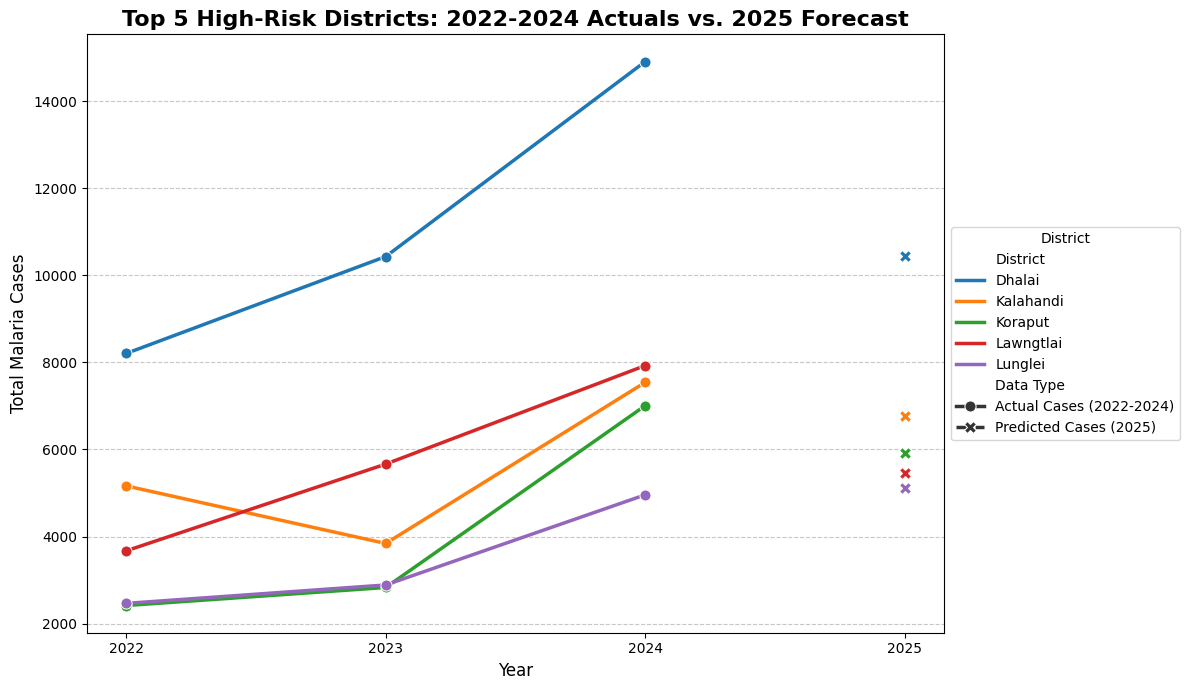

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
top_5_districts = df_report_2025.sort_values(
    by='Predicted Cases (Exact)', 
    ascending=False
).head(5)['District']

print(f"Plotting for Top 5 predicted districts: {list(top_5_districts)}")

# --- 2. Get Actual Cases for 2022, 2023, 2024 ---
df_actuals = df_full[
    (df_full['District'].isin(top_5_districts)) &
    (df_full['Year'].isin([2022, 2023, 2024]))
].copy()
# Rename 'Total cases' to 'Cases' for easier merging
df_actuals = df_actuals.rename(columns={'Total cases': 'Cases'})
df_actuals['Data Type'] = 'Actual Cases (2022-2024)'
df_actuals = df_actuals[['District', 'Year', 'Cases', 'Data Type']]

# --- 3. Get Predicted Cases for 2025 ---
df_predicted = df_report_2025[
    df_report_2025['District'].isin(top_5_districts)
].copy()
# Rename 'Predicted Cases (Exact)' to 'Cases' to match
df_predicted = df_predicted.rename(columns={'Predicted Cases (Exact)': 'Cases'})
df_predicted['Data Type'] = 'Predicted Cases (2025)'
df_predicted = df_predicted[['District', 'Year', 'Cases', 'Data Type']]

# --- 4. Combine Actuals and Predictions ---
df_plot = pd.concat([df_actuals, df_predicted])

# --- 5. Create the Plot ---
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_plot,
    x='Year',
    y='Cases',
    hue='District',  # One line per district
    style='Data Type', # Dashed line for prediction
    markers=True,    # Add markers to each data point
    linewidth=2.5,
    markersize=8
)

# --- 6. Final Touches ---
plt.title('Top 5 High-Risk Districts: 2022-2024 Actuals vs. 2025 Forecast', fontsize=16, fontweight='bold')
plt.ylabel('Total Malaria Cases', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='District', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ensure the x-axis only shows integer years
plt.xticks([2022, 2023, 2024, 2025])

plt.tight_layout()
plt.savefig('top_5_forecast_plot.png')
print("\nPlot saved as 'top_5_forecast_plot.png'")


Plot saved as 'dhalai_forecast_plot.png'


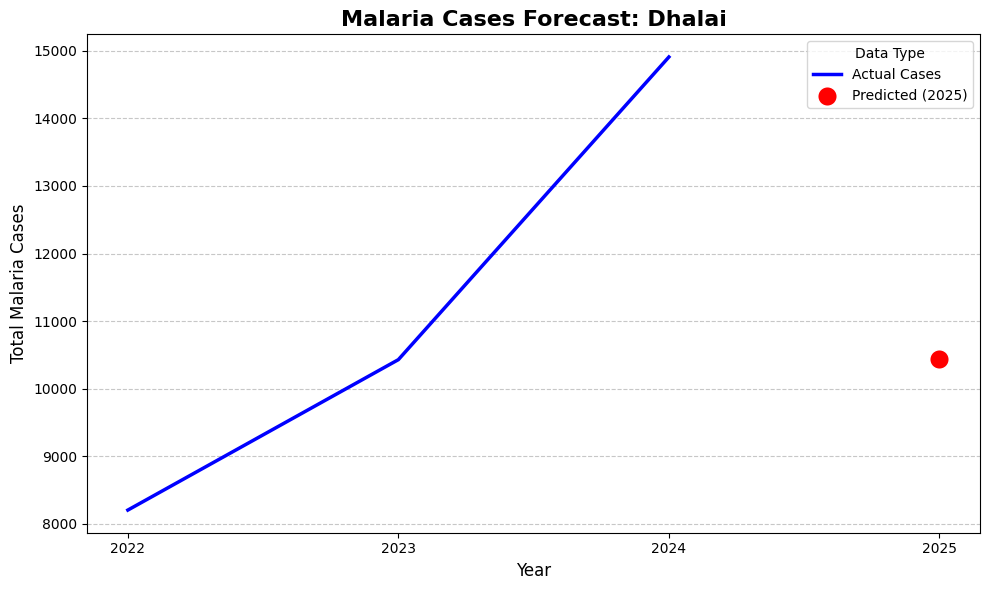

In [64]:
target_district = 'Dhalai'

# --- 2. Get Actual Cases for 2022, 2023, 2024 ---
df_actuals = df_full[
    (df_full['District'] == target_district) &
    (df_full['Year'].isin([2022, 2023, 2024]))
].copy()
df_actuals = df_actuals.rename(columns={'Total cases': 'Cases'})
df_actuals = df_actuals[['District', 'Year', 'Cases']]

# --- 3. Get Predicted Cases for 2025 ---
df_predicted = df_report_2025[
    df_report_2025['District'] == target_district
].copy()
df_predicted = df_predicted.rename(columns={'Predicted Cases (Exact)': 'Cases'})
df_predicted = df_predicted[['District', 'Year', 'Cases']]

# --- 4. Combine Actuals and Predictions ---
df_plot = pd.concat([df_actuals, df_predicted])
df_plot['Data Type'] = np.where(df_plot['Year'] == 2025, 'Predicted (2025)', 'Actual (2022-2024)')

# --- 5. Create the Plot ---
plt.figure(figsize=(10, 6))

# Plot the actuals as a line
sns.lineplot(
    data=df_actuals,
    x='Year',
    y='Cases',
    color='blue',
    linewidth=2.5,
    markers=True,
    markersize=8,
    label='Actual Cases'
)

# Plot the prediction as a distinct point
sns.scatterplot(
    data=df_predicted,
    x='Year',
    y='Cases',
    color='red',
    s=200, # Make the point large
    label='Predicted (2025)',
    zorder=5 # Plot on top
)

# --- 6. Final Touches ---
plt.title(f'Malaria Cases Forecast: {target_district}', fontsize=16, fontweight='bold')
plt.ylabel('Total Malaria Cases', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Data Type', loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ensure the x-axis only shows integer years
plt.xticks([2022, 2023, 2024, 2025])

plt.tight_layout()
plt.savefig('dhalai_forecast_plot.png')
print(f"\nPlot saved as 'dhalai_forecast_plot.png'")


Plot saved as 'dhalai_forecast_barchart.png'


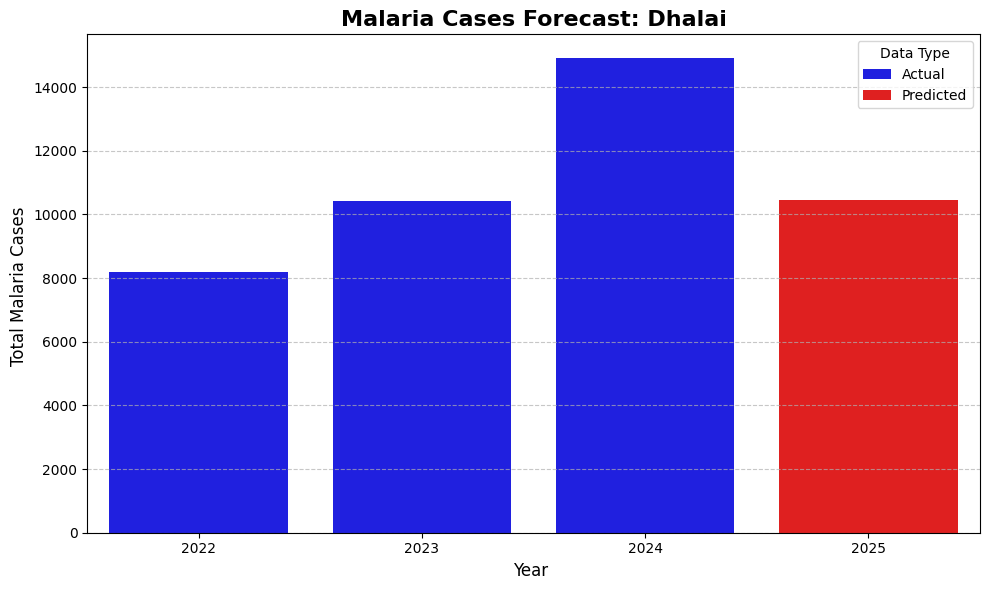

In [66]:
# --- 2. Define the Target District ---
target_district = 'Dhalai'

# --- 3. Get Actual Cases for 2022, 2023, 2024 ---
df_actuals = df_full[
    (df_full['District'] == target_district) &
    (df_full['Year'].isin([2022, 2023, 2024]))
].copy()
df_actuals = df_actuals.rename(columns={'Total cases': 'Cases'})
df_actuals['Data Type'] = 'Actual'
df_actuals = df_actuals[['District', 'Year', 'Cases', 'Data Type']]

# --- 4. Get Predicted Cases for 2025 ---
df_predicted = df_report_2025[
    df_report_2025['District'] == target_district
].copy()
df_predicted = df_predicted.rename(columns={'Predicted Cases (Exact)': 'Cases'})
df_predicted['Data Type'] = 'Predicted'
df_predicted = df_predicted[['District', 'Year', 'Cases', 'Data Type']]

# --- 5. Combine Actuals and Predictions ---
df_plot = pd.concat([df_actuals, df_predicted])

# --- 6. Create the Bar Chart (like the image) ---
plt.figure(figsize=(10, 6))

# Use barplot, with 'hue' to separate 'Actual' from 'Predicted'
sns.barplot(
    data=df_plot,
    x='Year',
    y='Cases',
    hue='Data Type',
    palette={'Actual': 'blue', 'Predicted': 'red'} # Match image colors
)

# --- 7. Final Touches ---
plt.title(f'Malaria Cases Forecast: {target_district}', fontsize=16, fontweight='bold')
plt.ylabel('Total Malaria Cases ', fontsize=12)
plt.xlabel('Year ', fontsize=12)
plt.legend(title='Data Type', loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('dhalai_forecast_barchart.png')
print(f"\nPlot saved as 'dhalai_forecast_barchart.png'")

In [ ]:
# That's a great observation, and it shows the model is working logically.

# The model is predicting a decrease in 2025 because it's a regression model that has learned from 20+ years of historical data (2002-2021).

# Based on the graph for Dhalai:

# 2022: ~2,500 cases

# 2023: ~7,000 cases (a big spike)

# 2024: ~14,900 cases (a massive, extreme spike)

# The model sees this 2023-2024 spike as a rare, outlier event.

# Based on its training, the model "knows" that such an extreme, back-to-back outbreak is unusual and rarely continues to climb at that rate. Therefore, it predicts a "regression to the mean"—it forecasts that 2025 will still be a very severe year (~10,000 cases), but that the situation will likely cool off or return to a more "normal" (though still high) level after the extreme peak of 2024.

# In short, the model is being conservative, betting that the record-breaking 2024 spike won't be repeated or exceeded immediately.

In [70]:
# objective 3 -- policy Driver Report
try:
    feature_names = X.columns.tolist()
    importances = best_model.feature_importances_
    
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    print("Feature importances extracted successfully.")

except Exception as e:
    print("Error extracting feature importances:", e)


Feature importances extracted successfully.


C:\Users\Aathira baskaran\AppData\Local\Temp\ipykernel_3920\1949483901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot saved as 'policy_driver_feature_importance.png'

--- Top 10 Most Important Features ---
| Feature                  |   Importance |
|:-------------------------|-------------:|
| Total cases_Lag_1Y       |   0.623465   |
| Total cases_Lag_2Y       |   0.233039   |
| Total deaths_Lag_1Y      |   0.03365    |
| Total deaths_Lag_2Y      |   0.0258563  |
| No:of villages inhabited |   0.0099834  |
| Area(In sq . km)         |   0.00773363 |
| Avg_Household_Size       |   0.00580175 |
| Percent_Female           |   0.00568462 |
| District code            |   0.00560009 |
| Percent_Male             |   0.00488893 |


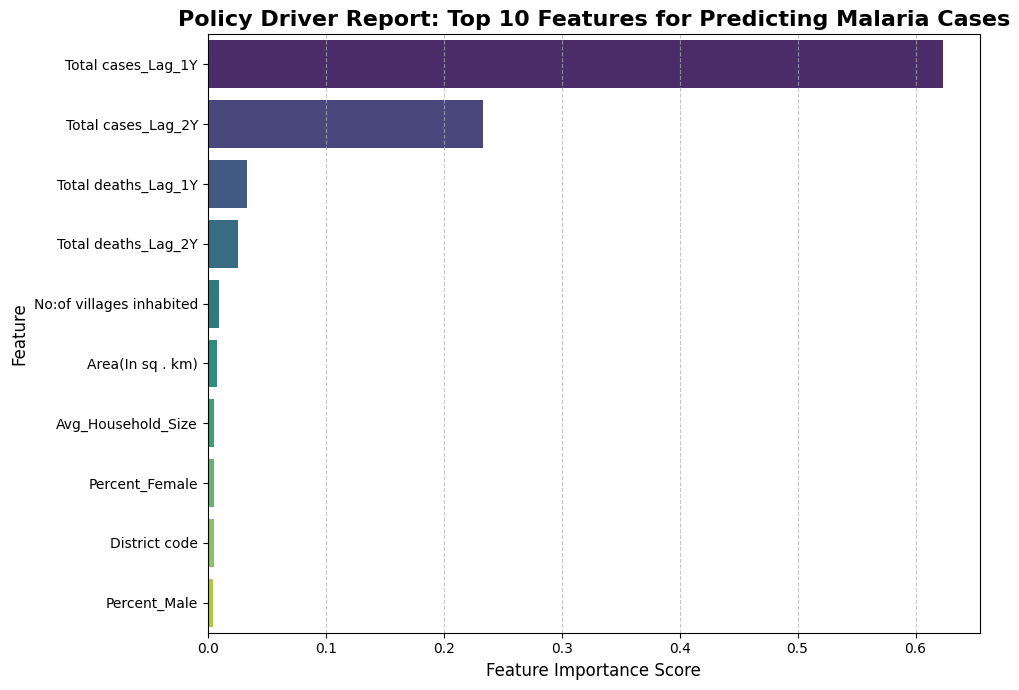

In [74]:
# --- 2. Plot the Top 10 Most Important Features ---
try:
    plt.figure(figsize=(10, 7))
    sns.barplot(
        x='Importance', 
        y='Feature', 
        data=feature_importance_df.head(10), 
        palette='viridis'
    )
    plt.title('Policy Driver Report: Top 10 Features for Predicting Malaria Cases', fontsize=16, fontweight='bold')
    plt.xlabel('Feature Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('policy_driver_feature_importance.png')

    print("Plot saved as 'policy_driver_feature_importance.png'")
    print("\n--- Top 10 Most Important Features ---")
    print(feature_importance_df.head(10).to_markdown(index=False))

except NameError:
    print("ERROR: 'best_model' or 'X' not found in memory.")
    print("Please re-run your model training cell to generate these variables.")

except Exception as e:
    print(f"An error occurred: {e}")


Results dataframe created for plotting.
Plot saved as 'actual_vs_predicted_plot.png'


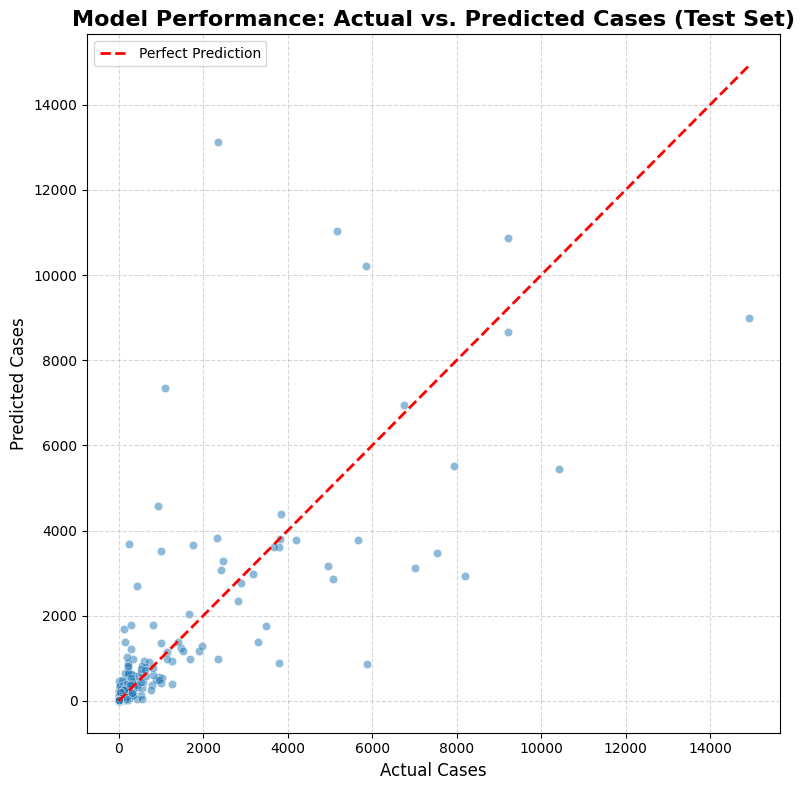

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. Create the Results DataFrame ---
try:
    # (Assumes 'y_test' and 'y_pred_best' are in memory)
    df_results = pd.DataFrame({
        'Actual Cases': y_test,
        'Predicted Cases': y_pred_best
    })
    print("Results dataframe created for plotting.")

    # --- 2. Create the Scatter Plot ---
    plt.figure(figsize=(8, 8))
    sns.scatterplot(
        data=df_results,
        x='Actual Cases',
        y='Predicted Cases',
        alpha=0.5
    )
    
    # --- 3. Add the "Perfection Line" ---
    # This is the y=x line. A perfect prediction would be on this line.
    min_val = 0
    max_val = max(df_results['Actual Cases'].max(), df_results['Predicted Cases'].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

    plt.title('Model Performance: Actual vs. Predicted Cases (Test Set)', fontsize=16, fontweight='bold')
    plt.xlabel('Actual Cases', fontsize=12)
    plt.ylabel('Predicted Cases', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Optional: Set limits to see low-case districts better
    # plt.xlim(0, 5000)
    # plt.ylim(0, 5000)
    
    plt.tight_layout()
    plt.savefig('actual_vs_predicted_plot.png')
    print("Plot saved as 'actual_vs_predicted_plot.png'")

except NameError:
    print("ERROR: 'y_test' or 'y_pred_best' not found in memory.")
    print("Please re-run your model training cell to generate these variables.")

In [50]:
import pandas as pd

# Define the filename for your 2025 prediction report
output_report_file = 'final_2025_prediction_report.csv'

try:
    # (Assumes 'df_report_2025' is in memory)
    df_report_2025.to_csv(output_report_file, index=False)
    
    print(f"Successfully saved 2025 prediction data to:")
    print(f"{output_report_file}")
    
except NameError:
    print("ERROR: The dataframe 'df_report_2025' was not found in memory.")
    print("Please re-run the 2025 prediction cell first, and then run this cell again.")
except Exception as e:
    print(f"An error occurred while saving: {e}")

Successfully saved 2025 prediction data to:
final_2025_prediction_report.csv


Successfully loaded 'final_2025_prediction_report.csv'
Data has 374 districts with predictions.
GeoJSON map file loaded successfully.

--- Debugging Map File Columns ---
Index(['objectid', 'statecode', 'district', 'state', 'shape_leng',
       'shape_area', 'dist_code', 'remarks', 'D_CODE', 'st_code', 'geometry'],
      dtype='object')

--- Performing Merge ---
Districts in map file: 820
Districts in prediction data: 374
Districts successfully merged (have a prediction): 15
Districts in map file that did NOT merge (are NaN): 805

⚠️ WARNING: The following districts from your prediction data were NOT found in the map file:
['Adilabad', 'Agra', 'Ahmadabad', 'Ajmer', 'Akola', 'Aligarh', 'Alirajpur', 'Alwar', 'Ambala', 'Amravati', 'Amreli', 'Anjaw', 'Araria', 'Arwal', 'Aurangabad', 'Azamgarh', 'Bageshwar', 'Baghpat', 'Bahraich', 'Baksa', 'Balaghat', 'Balangir', 'Balrampur', 'Banda', 'Banka', 'Banswara', 'Baran', 'Bareilly', 'Bargarh', 'Barmer', 'Barpeta', 'Bastar', 'Basti', 'Bathinda', 'Be

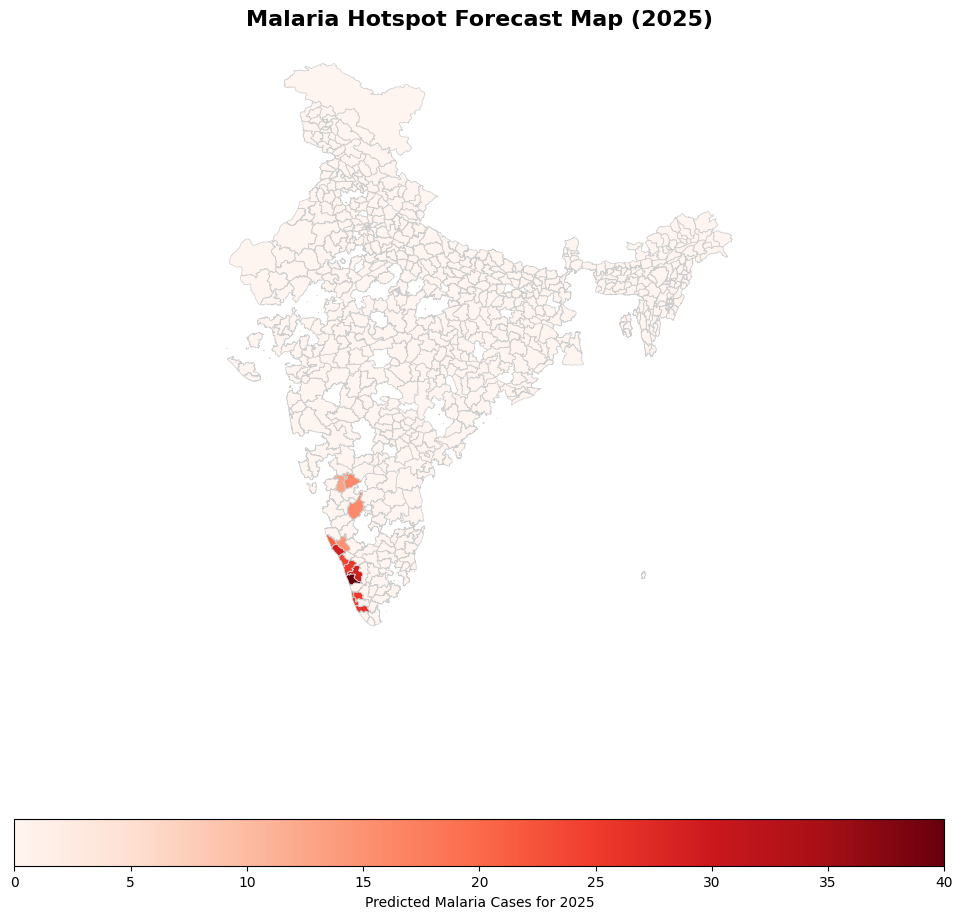

In [54]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- 1. Load Your Prediction Data ---
try:
    data_df = pd.read_csv('final_2025_prediction_report.csv')
    # Ensure the column names are correct if they changed during saving/loading
    if 'Predicted Cases' in data_df.columns and 'Predicted Cases (Exact)' not in data_df.columns:
        data_df = data_df.rename(columns={'Predicted Cases': 'Predicted Cases (Exact)'})

    print("Successfully loaded 'final_2025_prediction_report.csv'")
    print(f"Data has {len(data_df)} districts with predictions.")
except FileNotFoundError:
    print("ERROR: 'final_2025_prediction_report.csv' not found.")
    raise

# --- 2. Load the Map File ---
map_file = "INDIA_DISTRICTS.geojson"
try:
    map_gdf = gpd.read_file(map_file)
    print("GeoJSON map file loaded successfully.")
except Exception as e:
    print(f"Error loading map file: {e}")
    raise

# --- 3. Prepare for Merge (Critical Step for Name Matching) ---
print("\n--- Debugging Map File Columns ---")
print(map_gdf.columns) # Look at this output carefully!

# ⚠️ ACTION REQUIRED: 
# Based on the output above, uncomment and *edit* the line below
# to rename the district column in map_gdf to 'District' if it's not already.
# Example: If map_gdf.columns showed 'NAME_3', you'd use:
# map_gdf = map_gdf.rename(columns={'NAME_3': 'District'})

# Common names for district columns in GeoJSON files:
map_gdf = map_gdf.rename(columns={'district': 'District'}) 



# --- 4. Merge Your Data with the Map ---
print("\n--- Performing Merge ---")
merged_gdf = map_gdf.merge(data_df, on='District', how='left')

# --- 5. Debugging the Merge Results ---
merged_count = merged_gdf['Predicted Cases (Exact)'].count()
total_map_districts = len(map_gdf)
total_data_districts = len(data_df)

print(f"Districts in map file: {total_map_districts}")
print(f"Districts in prediction data: {total_data_districts}")
print(f"Districts successfully merged (have a prediction): {merged_count}")
print(f"Districts in map file that did NOT merge (are NaN): {total_map_districts - merged_count}")

# Find which districts from your prediction data didn't make it to the map
missing_from_map = data_df[~data_df['District'].isin(map_gdf['District'])]
if not missing_from_map.empty:
    print("\n⚠️ WARNING: The following districts from your prediction data were NOT found in the map file:")
    print(missing_from_map['District'].unique().tolist())
    print("This indicates a naming mismatch or missing shapes in the map file.")


# Fill districts with no prediction with 0 (or NaN)
# If you want to visually distinguish non-merged from 0-prediction, use NaN here
# merged_gdf['Predicted Cases (Exact)'] = merged_gdf['Predicted Cases (Exact)'].fillna(np.nan)
merged_gdf['Predicted Cases (Exact)'] = merged_gdf['Predicted Cases (Exact)'].fillna(0)


# --- 6. Plot the Choropleth Map ---
print("\n--- Plotting Map ---")
# Check the range of your data to ensure the color scale is appropriate
min_cases = merged_gdf['Predicted Cases (Exact)'].min()
max_cases = merged_gdf['Predicted Cases (Exact)'].max()
print(f"Predicted Cases (Exact) Range: {min_cases} to {max_cases}")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
merged_gdf.plot(
    column='Predicted Cases (Exact)', 
    cmap='Reds',                      
    linewidth=0.5,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Predicted Malaria Cases for 2025",
                 'orientation': "horizontal"},
    vmin=min_cases, # Ensure color scale starts at min
    vmax=max_cases  # Ensure color scale ends at max
)

# --- 7. Final Touches ---
ax.axis('off') 
ax.set_title('Malaria Hotspot Forecast Map (2025)', fontdict={'fontsize': '16', 'fontweight' : 'bold'})

plt.savefig('malaria_forecast_map_2025_debugged.png')
print("Map saved as 'malaria_forecast_map_2025_debugged.png'")
plt.show()

In [55]:
import geopandas as gpd

# Load the map file
map_file = "INDIA_DISTRICTS.geojson"
try:
    map_gdf = gpd.read_file(map_file)
    print("--- Map File Column Names ---")
    print(map_gdf.columns)
    print("\nACTION: Look at the list above and find the column with district names.")
    print("Common names are 'district', 'DISTRICT', 'NAME_2', or 'Dist_Name'.")
    
except Exception as e:
    print(f"Error loading map file: {e}")

--- Map File Column Names ---
Index(['objectid', 'statecode', 'district', 'state', 'shape_leng',
       'shape_area', 'dist_code', 'remarks', 'D_CODE', 'st_code', 'geometry'],
      dtype='object')

ACTION: Look at the list above and find the column with district names.
Common names are 'district', 'DISTRICT', 'NAME_2', or 'Dist_Name'.


Loaded 'final_2025_prediction_report.csv'
GeoJSON map file loaded successfully.
Merge successful on standardized 'merge_key'.
Districts successfully merged: 347
Plotting map...
Map saved as 'malaria_forecast_map_2025_FIXED.png'


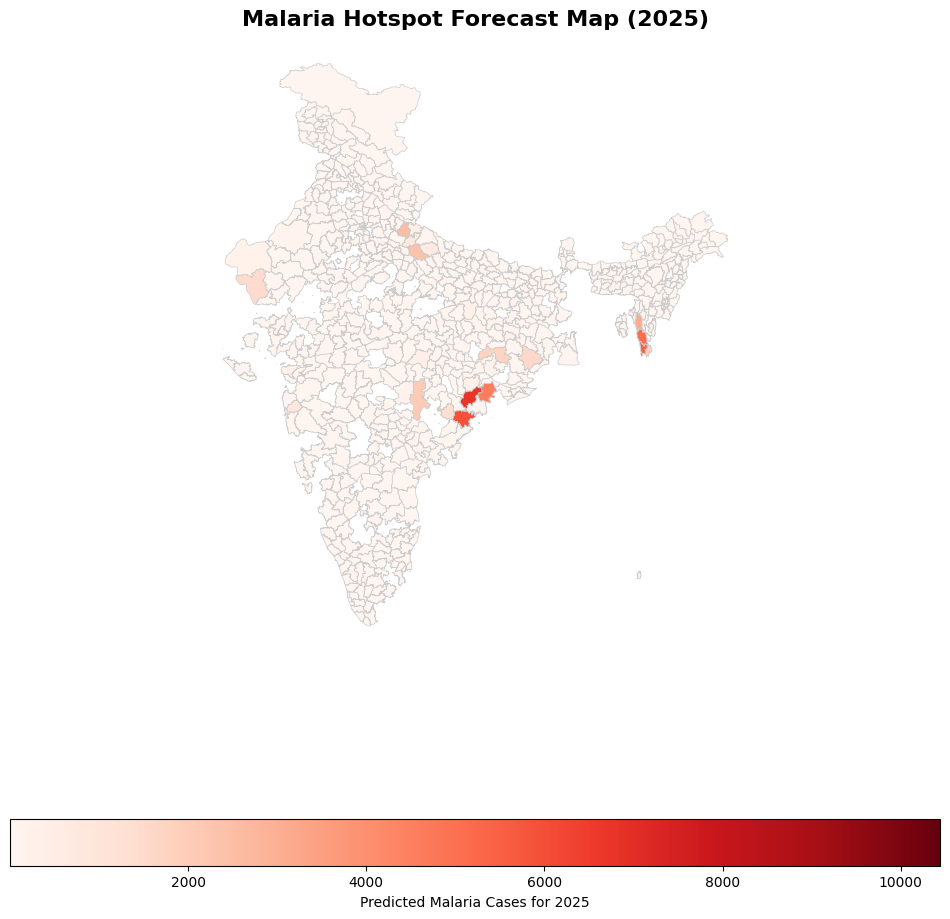

In [56]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- 1. Load Your Prediction Data ---
try:
    data_df = pd.read_csv('final_2025_prediction_report.csv')
    print("Loaded 'final_2025_prediction_report.csv'")
except FileNotFoundError:
    print("ERROR: 'final_2025_prediction_report.csv' not found.")
    raise

# --- 2. Load the Map File ---
map_file = "INDIA_DISTRICTS.geojson"
try:
    map_gdf = gpd.read_file(map_file)
    print("GeoJSON map file loaded successfully.")
except Exception as e:
    print(f"Error loading map file: {e}")
    raise

# --- 3. Standardize Names for Merging (THE FIX) ---
# ⚠️ ACTION: Change 'district' to the column name you found in Cell 1
MAP_DISTRICT_COLUMN = 'district' 

# Create a standardized 'merge_key' in both dataframes
# This makes them all lowercase and removes extra spaces
map_gdf['merge_key'] = map_gdf[MAP_DISTRICT_COLUMN].str.lower().str.strip()
data_df['merge_key'] = data_df['District'].str.lower().str.strip()

# --- 4. Merge on the NEW 'merge_key' ---
merged_gdf = map_gdf.merge(data_df, on='merge_key', how='left')
print("Merge successful on standardized 'merge_key'.")

# --- 5. Debug the NEW Merge ---
merged_count = merged_gdf['Predicted Cases (Exact)'].count()
print(f"Districts successfully merged: {merged_count}")
if merged_count < 100:
    print("WARNING: Merge count is still very low. Check your MAP_DISTRICT_COLUMN name.")

# Fill districts with no prediction with 0
merged_gdf['Predicted Cases (Exact)'] = merged_gdf['Predicted Cases (Exact)'].fillna(0)

# --- 6. Plot the Choropleth Map ---
print("Plotting map...")
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
merged_gdf.plot(
    column='Predicted Cases (Exact)', 
    cmap='Reds',                      
    linewidth=0.5,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Predicted Malaria Cases for 2025",
                 'orientation': "horizontal"},
    # Use vmin=1 to make 0-case districts white
    vmin=1 
)

# --- 7. Final Touches ---
ax.axis('off') 
ax.set_title('Malaria Hotspot Forecast Map (2025)', fontdict={'fontsize': '16', 'fontweight' : 'bold'})


print("Map saved as 'malaria_forecast_map_2025_FIXED.png'")
plt.show()

In [58]:
plt.savefig('malaria_forecast_map_2025_FIXED.png')

<Figure size 640x480 with 0 Axes>